# 2. Applying CloneTrast

This tutorial demonstrates how to apply CloneTrast on gene expression data to embed T cells, predict clone size, visualize clonal structure, evaluate batch mixing, and quantify clonal purity.

## **Pay attention (!):**

Here we use the same example dataset from our first tutorial (following our own QC and pre-processing pipeline).

Alternatively, you can use your own dataset directly, with your specific pre-processing steps (as long as it contains raw UMI counts of T cells, with genes represented as Ensembl IDs).

## Example Dataset

We use a publicly available paired scRNA/TCR-seq dataset of patients with brain tumors from:

- **Study**: Wang et al. 2024
- **Source**: https://zenodo.org/records/10672442
- **Data type**: Paired scRNA/TCR-seq
- **Cancer type**: Brain tumors
- **Tissue**: Tumor and blood samples

The input AnnData used here is the **pre-processed** output of tutorial 1 (`1. data_preparation_tutorial.ipynb`).

## Workflow Overview

1. **Pre-processed Data Loading** - Load the prepared AnnData and normalize expression
2. **Apply CloneTrast** - Embed cells, compute CloneTrast UMAP, and predict clone size
3. **Visualize predictions** - Compare CloneTrast embeddings to a standard Harmony UMAP and highlight large clones
4. **Evaluate batch mixing with iLISI** - Compare patient/sample mixing across CloneTrast, Harmony, and all-genes UMAPs
5. **Evaluate clonal purity** - Compare clonal cohesion across CloneTrast, PCA, and Harmony embeddings

---


## **Important note (!):**

At inference, CloneTrast uses **gene expression only**. Optional `clone_id` / `clone_id_size` labels are used here for visualization and comparison, not as model inputs.

## 1. Pre-processed Data Loading

In this section, we set up the environment, load the pre-processed AnnData from tutorial 1, and normalize gene expression for visualization and embedding.

In [1]:
# Add project src so "import clonetrast as ct" works (run this cell first)
import sys
from pathlib import Path

_root = Path.cwd()
if _root.name == "notebooks":
    _root = _root.parent
if not (_root / "src" / "clonetrast").exists():
    _root = _root.parent
# Package lives in src/clonetrast, so add src to path
sys.path.insert(0, str(_root / "src"))
print("Project root:", _root)

Project root: c:\Users\KerenYlab\OneDrive - Technion\Github_repos\CloneTrast


In [2]:
# Import required libraries for data analysis, visualization, and single-cell processing
import os
import numpy as np
import scanpy as sc
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import clonetrast as ct

print(f"CloneTrast {ct.__version__}")

# Set matplotlib backend for Jupyter notebooks
%matplotlib inline

# Plotting settings
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.axisbelow"] = True
sns.set_style("whitegrid")

# Setup project paths
project_root = Path.cwd().parent.parent
print(f"Project root: {project_root}")
sys.path.insert(0, str(project_root))

CloneTrast 0.1.0
Project root: c:\Users\KerenYlab\OneDrive - Technion\Github_repos\CloneTrast


### 1.1 Load AnnData

Load the pre-processed brain-tumor dataset. Gene names should be Ensembl IDs for compatibility with CloneTrast checkpoints.

In [3]:
demo_path = project_root / "data" / "demo"
cache_dir = demo_path / ".zenodo_cache"
source_path = demo_path / "Raw_files"

In [4]:
adata = sc.read(os.path.join(source_path, "CloneTrast_preprocessed_data_Brain_zenodo.h5ad"))
adata

AnnData object with n_obs × n_vars = 37020 × 23767
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_scores', 'predicted_doublets', 'tissue_type', 'clone_id', 'receptor_type', 'cancer_type', 'study', 'imputed_labels', 'patient', 'clone_id_size'
    var: 'gene_name', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts'

### 1.2 Normalize Expression

Normalize library size and log-transform counts before embedding and plotting.

In [5]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

## 2. Apply CloneTrast

We embed cells with the contrastive model, compute a UMAP in CloneTrast space, then predict per-cell clone size with the complementary size model.

### 2.1 Device Setup

Select GPU if available.

In [6]:
import torch

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version: {torch.version.cuda}")

Using device: cuda
  GPU: NVIDIA RTX 6000 Ada Generation
  CUDA version: 12.8


### 2.2 Embed Cells

Map each cell to the CloneTrast latent space (`adata.obsm['X_clonetrast']`).

This function will download the pre-trained contrastive model on first use.

In [7]:
ct.tl.embed(adata, device=device, use_pretrained=True)

[CloneTrast] Downloading pretrained bundle to C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\_downloads\contrastive_model.zip ...


contrastive_model.zip: 100%|██████████| 891M/891M [01:12<00:00, 12.8MB/s] 


[CloneTrast] Extracting pretrained bundle → C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\contrastive_model ...
[CloneTrast] Loading expression from layer/X and aligning to 11950 training genes...
[CloneTrast] Gene alignment: 37020 cells × 11950 training genes | matched 11949, missing (→0) 1, extra dropped 11818
[CloneTrast] Loading model from C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\contrastive_model...
[CloneTrast] Computing expression embeddings for 37020 cells (batch_size=512, device=cuda)...
[CloneTrast] Expression embeddings done: shape (37020, 1024) → adata.obsm['X_clonetrast']


AnnData object with n_obs × n_vars = 37020 × 23767
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_scores', 'predicted_doublets', 'tissue_type', 'clone_id', 'receptor_type', 'cancer_type', 'study', 'imputed_labels', 'patient', 'clone_id_size'
    var: 'gene_name', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    obsm: 'X_clonetrast'
    layers: 'counts'

### 2.3 Compute CloneTrast UMAP

Build a 2D UMAP from the CloneTrast embedding for visualization.

In [8]:
ct.tl.compute_umap(adata, obsm_key="X_clonetrast", umap_key="X_umap_clonetrast")

c:\Users\KerenYlab\OneDrive - Technion\Github_repos\CloneTrast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\KerenYlab\OneDrive - Technion\Github_repos\CloneTrast\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[CloneTrast] Neighbor graph saved to adata.obsp['connectivities_umap_clonetrast'], adata.obsp['distances_umap_clonetrast'], adata.uns['neighbors_umap_clonetrast']


AnnData object with n_obs × n_vars = 37020 × 23767
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_scores', 'predicted_doublets', 'tissue_type', 'clone_id', 'receptor_type', 'cancer_type', 'study', 'imputed_labels', 'patient', 'clone_id_size'
    var: 'gene_name', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'neighbors_umap_clonetrast'
    obsm: 'X_clonetrast', 'X_umap_clonetrast'
    layers: 'counts'
    obsp: 'connectivities_umap_clonetrast', 'distances_umap_clonetrast'

### 2.4 Predict Clone Size

Predict log clone size per cell (`adata.obs['predicted_clone_size']`) using the clone-size model checkpoint.

This function will download the pre-trained size model on first use.

In [ ]:
ct.tl.predict_clone_size(
    adata,
    obs_key="predicted_clone_size",
    device=device,
    use_pretrained=True
)

[CloneTrast] Downloading pretrained bundle to C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\_downloads\clone_size_model.zip ...


clone_size_model.zip: 100%|██████████| 153M/153M [01:17<00:00, 2.07MB/s] 


[CloneTrast] Extracting pretrained bundle → C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\clone_size_model ...
[CloneTrast] Aligning expression to training genes for clone size prediction...
[CloneTrast] Gene alignment: 37020 cells × 11950 training genes | matched 11949, missing (→0) 1, extra dropped 11818
[CloneTrast] Loading size model from C:\Users\KerenYlab\.cache\clonetrast\pretrained_models\clone_size_model...
[CloneTrast] Predicting clone size for 37020 cells...
[CloneTrast] Clone size predictions → adata.obs['predicted_clone_size']


AnnData object with n_obs × n_vars = 37020 × 23767
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_scores', 'predicted_doublets', 'tissue_type', 'clone_id', 'receptor_type', 'cancer_type', 'study', 'imputed_labels', 'patient', 'clone_id_size', 'predicted_clone_size'
    var: 'gene_name', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'neighbors_umap_clonetrast'
    obsm: 'X_clonetrast', 'X_umap_clonetrast'
    layers: 'counts'
    obsp: 'connectivities_umap_clonetrast', 'distances_umap_clonetrast'

## 3. Visualize Predictions

Compare CloneTrast embeddings to a standard Harmony-corrected expression UMAP, and highlight large clones in both spaces.

### 3.1 Standard Harmony UMAP Baseline

Compute a conventional expression embedding (HVG → PCA → Harmony → UMAP).

In [10]:
sc.pp.highly_variable_genes(adata)
sc.tl.pca(adata, use_highly_variable = True)
import harmonypy as hm
ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, ["sample"])

C:\Users\KerenYlab\AppData\Local\Temp\ipykernel_7324\1926775119.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, use_highly_variable = True)
2026-10-01 09:29:48,226 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-10-01 09:29:48,226 - harmonypy - INFO -   Parameters:
2026-10-01 09:29:48,226 - harmonypy - INFO -     max_iter_harmony: 10
2026-10-01 09:29:48,227 - harmonypy - INFO -     max_iter_kmeans: 20
2026-10-01 09:29:48,227 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-10-01 09:29:48,227 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-10-01 09:29:48,228 - harmonypy - INFO -     nclust: 100
2026-10-01 09:29:48,228 - harmonypy - INFO -     block_size: 0.05
2026-10-01 09:29:48,228 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

In [11]:
adata.obsm["X_pca_harmony"] = ho.Z_corr
sc.pp.neighbors(adata, use_rep="X_pca_harmony", key_added="neighbors_umap_harmony")
sc.tl.umap(adata, neighbors_key="neighbors_umap_harmony", key_added="X_umap_harmony")

### 3.2 Compare True vs Predicted Clone Size

Switch gene index to gene symbols for plotting, log-transform true clone size to match the prediction scale, and color both UMAPs by true and predicted clone size.

In [12]:
adata.var = adata.var.reset_index().set_index('gene_name')

In [13]:
# to match the prediction value scale of CloneTrast
adata.obs['clone_id_size'] = np.log(adata.obs['clone_id_size'])

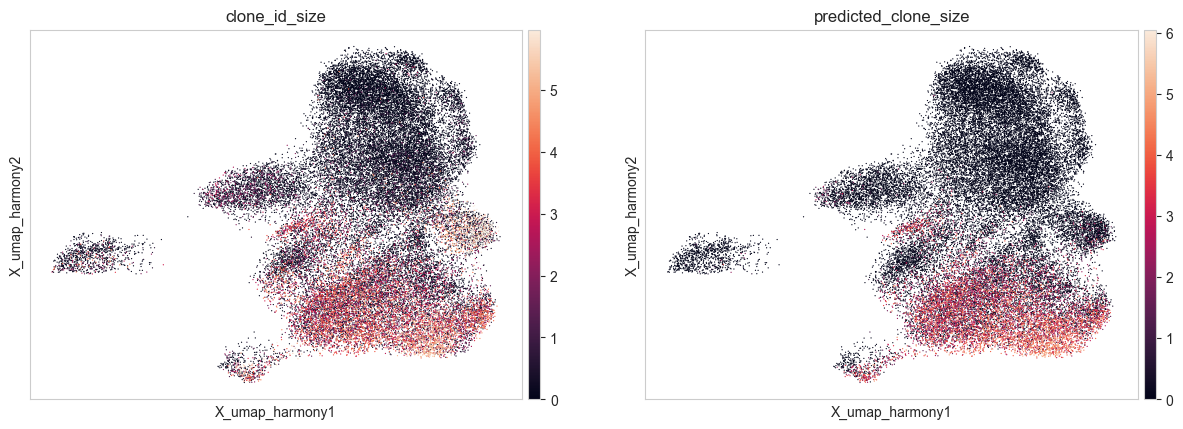

In [14]:
sc.pl.embedding(
        adata,
        basis='X_umap_harmony',
        color = ['clone_id_size', 'predicted_clone_size']
    )

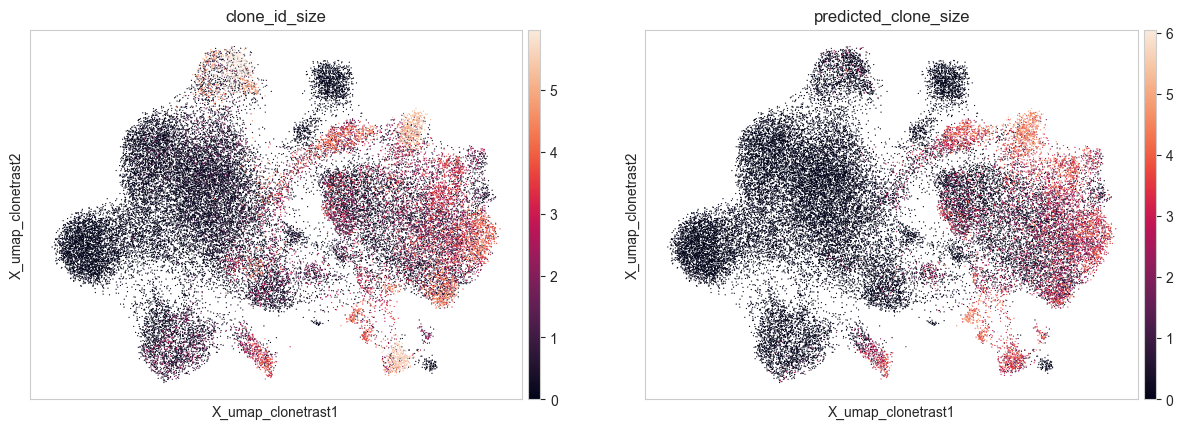

In [15]:
sc.pl.embedding(
        adata,
        basis='X_umap_clonetrast',
        color = ['clone_id_size', 'predicted_clone_size']
    )

### 3.3 Highlight Top-Size Clones

Label clones larger than 50 cells and overlay them on both CloneTrast and standard UMAPs to inspect clonal cohesion.

In [16]:
adata.obs['top_clones'] = adata.obs.apply(
    lambda row: f'{row["clone_id"]}' if np.exp(row["clone_id_size"]) > 50 else np.nan,
    axis=1
)

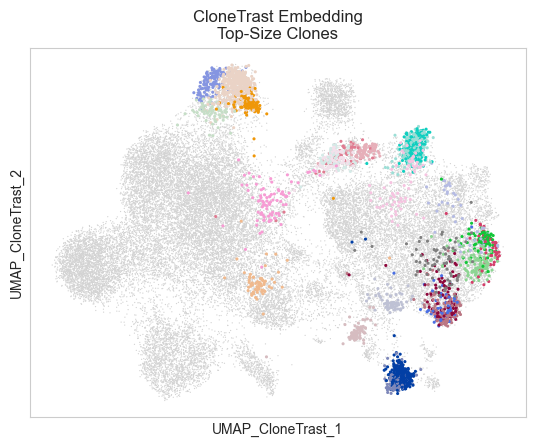

In [17]:
mask = ~adata.obs["top_clones"].isna()

fig, ax = plt.subplots()

# background (all cells, small)
sc.pl.embedding(
    adata,
    basis="X_umap_clonetrast",
    color="top_clones",
    na_color="lightgrey",
    na_in_legend=False, legend_loc = None,
    ax=ax,
    show=False
)

# overlay non-NA cells (bigger)
sc.pl.embedding(
    adata[mask],
    basis="X_umap_clonetrast",
    color="top_clones",
    title ='CloneTrast Embedding\nTop-Size Clones',
    size=20,
    na_in_legend=False, legend_loc = None,
    ax=ax,
    show=False
)
plt.xlabel('UMAP_CloneTrast_1')
plt.ylabel('UMAP_CloneTrast_2')
plt.show()

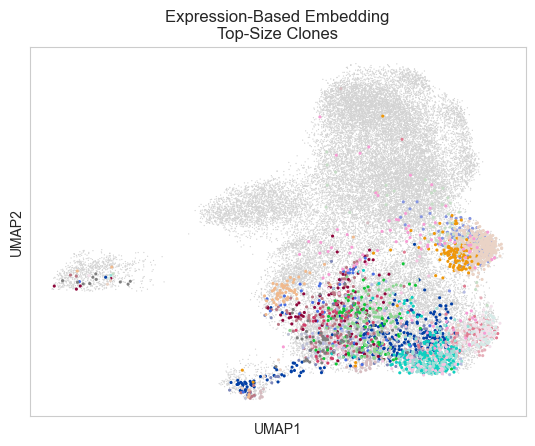

In [19]:
mask = ~adata.obs["top_clones"].isna()

fig, ax = plt.subplots()

# background (all cells, small)
sc.pl.embedding(
    adata,
    basis="X_umap_harmony",
    color="top_clones",
    na_color="lightgrey",
    na_in_legend=False, legend_loc = None,
    ax=ax, 
    show=False
)

# overlay non-NA cells (bigger)
sc.pl.embedding(
    adata[mask],
    basis="X_umap_harmony",
    color="top_clones",
    title ='Expression-Based Embedding\nTop-Size Clones',
    size=20,
    na_in_legend=False, legend_loc = None,
    ax=ax,
    show=False
)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

## 4. Evaluate Batch Mixing with iLISI

Use [iLISI](https://www.nature.com/articles/s41592-019-0619-0) to quantify sample mixing across embeddings and assess batch-effect removal by CloneTrast. Higher iLISI indicates stronger mixing of cells from different samples.

Removal of batch effects between patients, as demonstrated here with iLISI, was achieved by **patient-wise batching during training**: each mini-batch is assembled from a small number of patients (the number of patients per batch was chosen by hyperparameter search). This encourages the model to learn within-patient clonal structure without confounding patient identity, while still allowing inter-patient clonal architecture to emerge in the shared embedding space.


### 4.1 All-Genes UMAP Baseline

Create a UMAP from PCA computed on all genes (not only highly variable genes) as an additional uncorrected baseline for comparison.


In [20]:
sc.tl.pca(adata, use_highly_variable=False)
sc.pp.neighbors(adata, use_rep="X_pca", key_added="neighbors_umap_all_genes")
sc.tl.umap(adata, neighbors_key="neighbors_umap_all_genes", key_added="X_umap_all_genes")

C:\Users\KerenYlab\AppData\Local\Temp\ipykernel_7324\2312043387.py:1: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, use_highly_variable=False)


### 4.2 Compute and Compare iLISI

Compute iLISI on the CloneTrast, Harmony, and all-genes UMAPs (batch key: `sample`), then compare the distributions with a violin plot and report median values.


In [21]:
from harmonypy import compute_lisi

ilisi_clonetrast = compute_lisi(
    adata.obsm["X_umap_clonetrast"],
    adata.obs,
    ["sample"],
    perplexity=30,
)
ilisi_harmony = compute_lisi(
    adata.obsm["X_umap_harmony"],
    adata.obs,
    ["sample"],
    perplexity=30,
)
ilisi_all_genes = compute_lisi(
    adata.obsm["X_umap_all_genes"],
    adata.obs,
    ["sample"],
    perplexity=30,
)

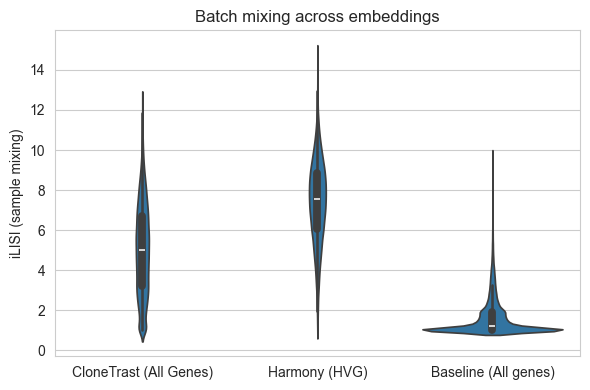

In [22]:
df_ilisi = pd.DataFrame({
    "CloneTrast (All Genes)": ilisi_clonetrast[:, 0],
    "Harmony (HVG)": ilisi_harmony[:, 0],
    "Baseline (All genes)": ilisi_all_genes[:, 0],
})

df_long = df_ilisi.melt(
    var_name="Embedding",
    value_name="iLISI",
)

plt.figure(figsize=(6, 4))
sns.violinplot(
    data=df_long,
    x="Embedding",
    y="iLISI",
    inner="box",
)
plt.ylabel("iLISI (sample mixing)")
plt.xlabel("")
plt.title("Batch mixing across embeddings")
plt.tight_layout()
plt.show()

In [23]:
print("Median iLISI per embedding:")
print(df_ilisi.median())

Median iLISI per embedding:
CloneTrast (All Genes)    5.005116
Harmony (HVG)             7.538726
Baseline (All genes)      1.201920
dtype: float64


Overall, this analysis shows that CloneTrast successfully removes batch effects between patients/samples, while preserving the biological structure of T-cell clones. That mixing reflects patient-wise batching during training, which supports learning both intra-patient and inter-patient clonal architecture.


## 5. Evaluate Clonal Purity

Use `ct.tl.evaluate_embeddings` to quantify how well each embedding groups cells from the same clone. The clonal purity score measures the fraction of a cell's *k* nearest neighbors (within the same patient) that share its `clone_id`. Higher scores indicate stronger clonal cohesion.

See the evaluation metrics documentation for details on how per-patient and overall purity scores are computed.


### 5.1 Compute Clonal Purity Scores

Compute clonal purity on the CloneTrast, PCA, and Harmony embeddings. Neighbors are restricted to the same patient via `patient_key`.


In [24]:
out_clonetrast = ct.tl.evaluate_embeddings(
    adata,
    obsm_key="X_clonetrast",
    clone_id_key="clone_id",
    patient_key="patient",
    k=10,
    min_clone_size=5,
    weight_by_cells=True,
    return_purity_per_patient=True,
)

overall_clonetrast = out_clonetrast["purity"]
per_patient_clonetrast = out_clonetrast["purity_per_patient"]

out_pca = ct.tl.evaluate_embeddings(
    adata,
    obsm_key="X_pca",
    clone_id_key="clone_id",
    patient_key="patient",
    k=10,
    min_clone_size=5,
    weight_by_cells=True,
    return_purity_per_patient=True,
)

overall_pca = out_pca["purity"]
per_patient_pca = out_pca["purity_per_patient"]

out_harmony = ct.tl.evaluate_embeddings(
    adata,
    obsm_key="X_pca_harmony",
    clone_id_key="clone_id",
    patient_key="patient",
    k=10,
    min_clone_size=5,
    weight_by_cells=True,
    return_purity_per_patient=True,
)

overall_harmony = out_harmony["purity"]
per_patient_harmony = out_harmony["purity_per_patient"]


### 5.2 Compare Purity Across Embeddings

Compare per-patient clonal purity scores across embeddings with a boxplot and overlay individual patients.


In [25]:
df = pd.concat(
    [
        pd.DataFrame.from_dict(per_patient_clonetrast, orient="index", columns=["CloneTrast"]),
        pd.DataFrame.from_dict(per_patient_pca, orient="index", columns=["PCA"]),
        pd.DataFrame.from_dict(per_patient_harmony, orient="index", columns=["Harmony"]),
    ],
    axis=1,
)

df_long = (
    df.reset_index()
    .rename(columns={"index": "patient"})
    .melt(
        id_vars="patient",
        var_name="method",
        value_name="value",
    )
)


C:\Users\KerenYlab\AppData\Local\Temp\ipykernel_7324\490865149.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(


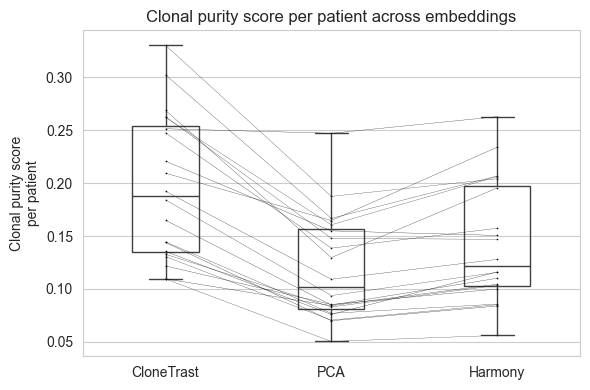

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_long,
    x="method",
    y="value",
    legend=False,
    boxprops={"facecolor": "None"},
    width=0.4,
    linewidth=1,
    fliersize=0,
)
sns.pointplot(
    data=df_long,
    x="method",
    y="value",
    hue="patient",
    legend=False,
    lw=0.2,
    color="black",
    markersize=1,
)
plt.title("Clonal purity score per patient across embeddings")
ax = plt.gca()
ax.set_xlabel("")
ax.set_ylabel("Clonal purity score\nper patient")
plt.tight_layout()
plt.show()


In [27]:
print("Overall clonal purity per embedding:")
print(pd.Series(
    {
        "CloneTrast": overall_clonetrast,
        "PCA": overall_pca,
        "Harmony": overall_harmony,
    },
    name="clonal_purity",
))


Overall clonal purity per embedding:
CloneTrast    0.174151
PCA           0.103833
Harmony       0.119512
Name: clonal_purity, dtype: float64


Overall, CloneTrast embeddings achieve higher clonal purity than standard PCA and Harmony baselines, indicating that cells from the same clone are more co-localized in the learned representation.
